In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# load both files
traffic = pd.read_csv("data_invented/traffic_table.csv").set_index("month")   # invented
arts = pd.read_csv("techi_articles.csv")                            # real
secs = ["AI", "Markets", "Crypto", "Breakthroughs", "Policy", "Guides"]
traffic["total"] = traffic[secs].sum(axis=1)
signups = traffic["newsletter_signups"]
scrape_day = pd.Timestamp("2026-10-03")   # the day I opened the pages
traffic

,AI,Markets,Crypto,Breakthroughs,Policy,Guides,newsletter_signups,total
month,,,,,,,,
2025-09,18400,12200,9800,7600,5400,4100,820,57500
2025-10,19100,12500,10100,7800,5500,4000,840,59000
2025-11,19800,12800,24800,8100,5600,3900,860,75000
2025-12,20500,13100,11000,8300,5700,3800,890,62400
2026-01,21200,13400,11400,8500,5800,3700,920,64000
2026-02,31610,19865,16820,12615,8555,5220,950,94685
2026-03,32480,20300,17255,12905,8700,4930,980,96570
2026-04,33350,20735,17545,13195,8845,2175,1010,95845
2026-05,34220,21170,17980,13485,8990,1595,1040,97440


In [2]:
# a) the 30% claim. table starts sep 2025 so there is no year-ago month
# closest pair is aug 2026 vs sep 2025 (11 months)
raw = traffic.total["2026-08"] / traffic.total["2025-09"] - 1
print("aug26 vs sep25 reported:", round(raw * 100, 1), "%")

aug26 vs sep25 reported: 78.8 %


In [3]:
# b) is the feb jump readers or measurement?
# normal month change, leaving out nov, dec and feb
normal = traffic.total.pct_change().drop(["2025-11", "2025-12", "2026-02"]).mean()
feb = traffic.total["2026-02"] / traffic.total["2026-01"] - 1
print("normal month:", round(normal * 100, 1), "%  feb:", round(feb * 100, 1), "%")

# what feb should have been for each section = jan + its own average monthly gain
gain = (traffic.loc["2026-01", secs] - traffic.loc["2025-09", secs]) / 4
expected_feb = traffic.loc["2026-01", secs] + gain
step = traffic.loc["2026-02", secs] / expected_feb
print(step.round(3))

# sessions per signup, signups come from a different system
print((traffic.total / signups).round(1))

normal month: 1.7 %  feb: 47.9 %
AI               1.443
Markets          1.450
Crypto           1.425
Breakthroughs    1.446
Policy           1.450
Guides           1.450
dtype: float64
month
2025-09    70.1
2025-10    70.2
2025-11    87.2
2025-12    70.1
2026-01    69.6
2026-02    99.7
2026-03    98.5
2026-04    94.9
2026-05    93.7
2026-06    92.6
2026-07    91.7
2026-08    90.2
dtype: float64


In [4]:
# one factor k for the whole site, plus a low and a high version
k = traffic.loc["2026-02", secs].sum() / expected_feb.sum()
k_low = step.min()
k_high = traffic.total["2026-02"] / traffic.total["2026-01"]   # assumes zero real growth in feb

for name, kk in [("central", k), ("low k", k_low), ("high k", k_high)]:
    fixed_aug = traffic.total["2026-08"] / kk
    print(name, round(kk, 3), "underlying", round((fixed_aug / traffic.total["2025-09"] - 1) * 100, 1), "%")

print("signups aug vs sep:", round((signups["2026-08"] / signups["2025-09"] - 1) * 100, 1), "%")

central 1.443 underlying 23.9 %
low k 1.425 underlying 25.4 %
high k 1.479 underlying 20.8 %
signups aug vs sep: 39.0 %


In [5]:
# november: crypto vs the average of oct and dec
cr = traffic["Crypto"]
extra = cr["2025-11"] - (cr["2025-10"] + cr["2025-12"]) / 2
print("extra crypto sessions:", extra, " share of nov site total:", round(extra / traffic.total["2025-11"] * 100), "%")
print("signups nov:", signups["2025-11"], " avg of oct/dec:", (signups["2025-10"] + signups["2025-12"]) / 2)

extra crypto sessions: 14250.0  share of nov site total: 19 %
signups nov: 860  avg of oct/dec: 865.0


In [6]:
# turn date_shown into real dates. relative ones use the scrape day
def to_date(text):
    m = re.match(r"(\d+) (hour|day)s? ago", text)
    if m:
        n = int(m.group(1))
        if m.group(2) == "hour":
            return (scrape_day - pd.Timedelta(hours=n)).normalize()
        return scrape_day - pd.Timedelta(days=n)
    return pd.to_datetime(text, format="%d-%b-%y")

arts["date"] = arts["date_shown"].map(to_date)

# how many days does each section's 20 newest articles cover
span = arts.groupby("section")["date"].agg(["min", "max"])
span["days_covered"] = (scrape_day - span["min"]).dt.days
print(span)

                     min        max  days_covered
section                                          
AI            2026-09-21 2026-10-02            12
Breakthroughs 2026-07-15 2026-09-26            80
Crypto        2026-04-18 2026-10-02           168
Guides        2026-03-11 2026-08-09           206
Markets       2026-07-09 2026-10-02            86
Policy        2026-05-09 2026-08-19           147


In [7]:
# guides: how many articles per month, and what formats
g = arts[arts["section"] == "Guides"]
print(g.groupby(g["date"].dt.to_period("M")).size())
print(g["format"].value_counts())
print("unique urls:", arts["url"].nunique(), "out of", len(arts))

date
2026-03     3
2026-05     3
2026-06     2
2026-07    11
2026-08     1
Freq: M, dtype: int64
format
guide        8
news         6
analysis     4
explainer    2
Name: count, dtype: int64
unique urls: 117 out of 120


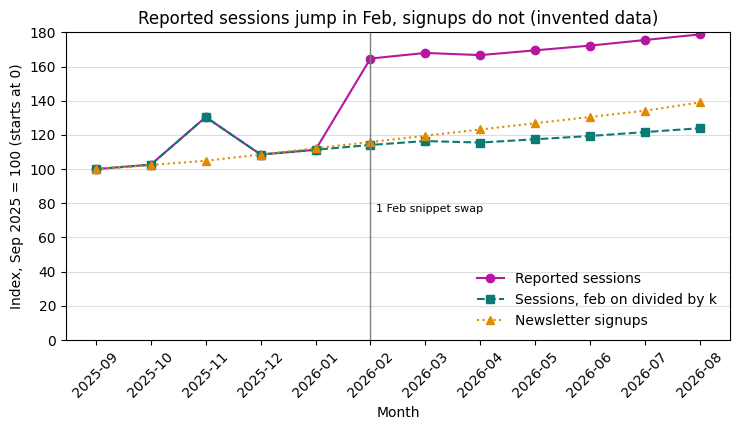

In [8]:
# chart 1: reported vs adjusted sessions vs signups (all set to sep 2025 = 100)
def idx(s):
    return s / s.iloc[0] * 100

adjusted = traffic.total.astype(float)
adjusted.iloc[5:] = adjusted.iloc[5:] / k     # feb onwards

plt.figure(figsize=(7.5, 4.4))
plt.plot(range(12), idx(traffic.total), color="#b5179e", marker="o", linestyle="-", label="Reported sessions")
plt.plot(range(12), idx(adjusted), color="#0b7a75", marker="s", linestyle="--", label="Sessions, feb on divided by k")
plt.plot(range(12), idx(signups), color="#e08a00", marker="^", linestyle=":", label="Newsletter signups")
plt.axvline(5, color="gray", linewidth=1)
plt.text(5.1, 75, "1 Feb snippet swap", fontsize=8)
plt.ylim(0, 180)
plt.xticks(range(12), traffic.index, rotation=45)
plt.ylabel("Index, Sep 2025 = 100 (starts at 0)")
plt.xlabel("Month")
plt.title("Reported sessions jump in Feb, signups do not (invented data)")
plt.grid(axis="y", color="#dddddd")
plt.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.savefig("charts/chart1_measurement_vs_readers.png", dpi=200)
plt.show()

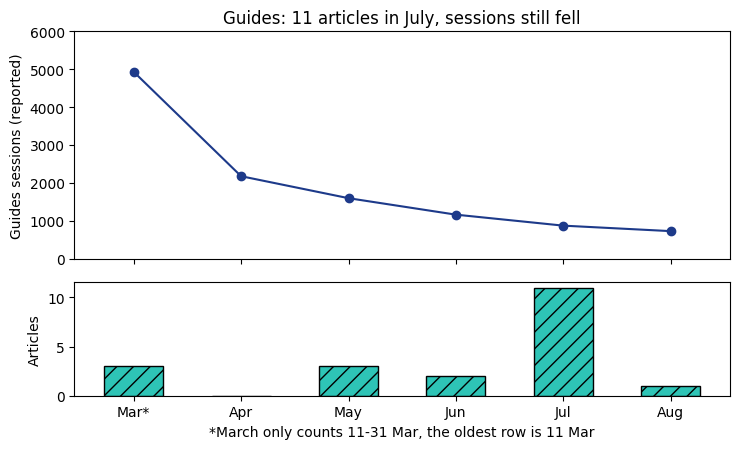

In [9]:
# chart 2: guides sessions and number of guides articles per month
months = ["2026-03", "2026-04", "2026-05", "2026-06", "2026-07", "2026-08"]
counts = [int(((g["date"].dt.to_period("M").astype(str)) == m).sum()) for m in months]

fig, (top, bottom) = plt.subplots(2, 1, figsize=(7.5, 4.6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
top.plot(range(6), traffic.loc[months, "Guides"], color="#1d3a8a", marker="o")
top.set_ylim(0, 6000)
top.set_ylabel("Guides sessions (reported)")
top.set_title("Guides: 11 articles in July, sessions still fell")
bottom.bar(range(6), counts, color="#2ec4b6", edgecolor="black", hatch="//", width=0.55)
bottom.set_ylabel("Articles")
bottom.set_xticks(range(6))
bottom.set_xticklabels(["Mar*", "Apr", "May", "Jun", "Jul", "Aug"])
bottom.set_xlabel("*March only counts 11-31 Mar, the oldest row is 11 Mar")
plt.tight_layout()
plt.savefig("charts/chart2_guides.png", dpi=200)
plt.show()